# Geographic Fraud Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import os
import sys
from pathlib import Path

# Find project root and set working directory
current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader

loader = DataLoader()
data = loader.load_all('train')
transactions = data['transactions']
customers    = data['customers']
terminals    = data['terminals']

print(f"Transactions : {len(transactions):,}")
print(f"Customers    : {len(customers):,}")
print(f"Terminals    : {len(terminals):,}")

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
Transactions : 291,231
Customers    : 1,000
Terminals    : 2,000


In [2]:
# ── Merge all tables ────────────────────────────────────────────────────────
merged = transactions.merge(customers, on='CUSTOMER_ID', how='left')
merged = merged.merge(terminals, on='TERMINAL_ID', how='left')

terminal_stats = (
    merged.groupby(['TERMINAL_ID', 'x_terminal_id', 'y_terminal_id'])
    .agg(fraud_rate=('TX_FRAUD', 'mean'), tx_count=('TX_FRAUD', 'count'))
    .reset_index()
)

fraud_txns  = merged[merged['TX_FRAUD'] == 1]
legit_txns  = merged[merged['TX_FRAUD'] == 0]
print(f"Merged shape: {merged.shape}")

Merged shape: (291231, 15)


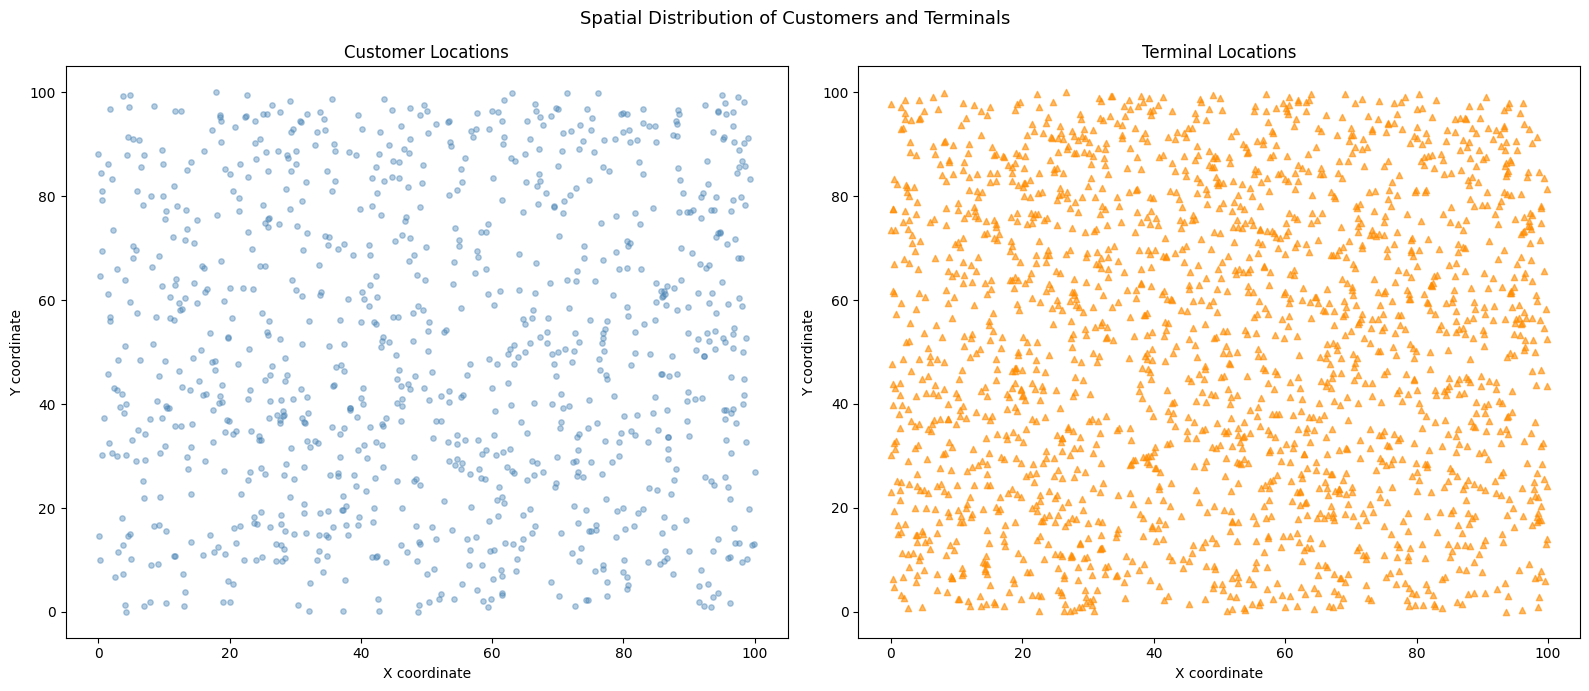

In [3]:
# ── 1. Customer & Terminal Locations ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(customers['x_customer_id'], customers['y_customer_id'],
                alpha=0.4, s=15, color='steelblue')
axes[0].set_title('Customer Locations')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')

axes[1].scatter(terminals['x_terminal_id'], terminals['y_terminal_id'],
                alpha=0.6, s=20, color='darkorange', marker='^')
axes[1].set_title('Terminal Locations')
axes[1].set_xlabel('X coordinate')
axes[1].set_ylabel('Y coordinate')

plt.suptitle('Spatial Distribution of Customers and Terminals', fontsize=13)
plt.tight_layout()
plt.show()

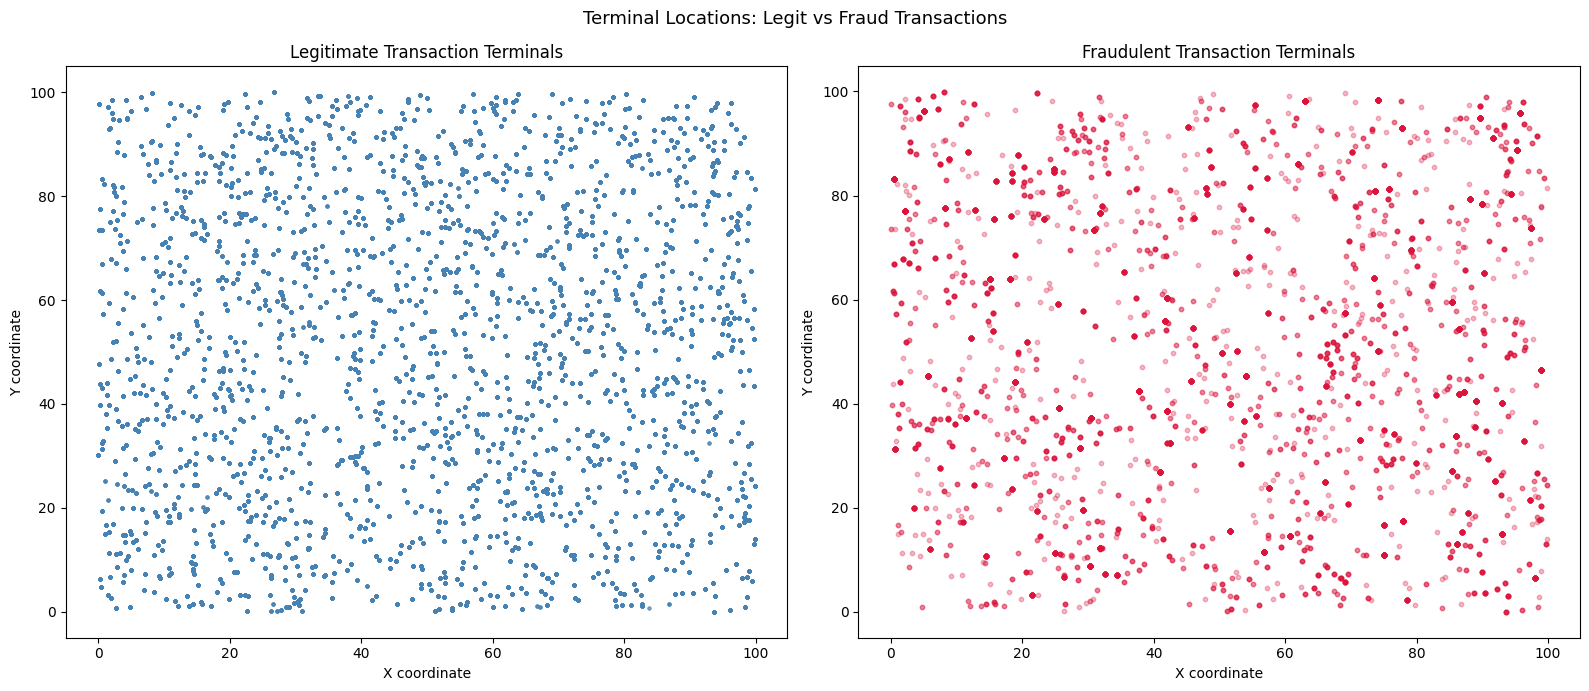

In [4]:
# ── 2. Fraud vs Legit Terminal Hotspots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(legit_txns['x_terminal_id'], legit_txns['y_terminal_id'],
                alpha=0.1, s=5, color='steelblue', label='Legit')
axes[0].set_title('Legitimate Transaction Terminals')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')

axes[1].scatter(fraud_txns['x_terminal_id'], fraud_txns['y_terminal_id'],
                alpha=0.3, s=10, color='crimson', label='Fraud')
axes[1].set_title('Fraudulent Transaction Terminals')
axes[1].set_xlabel('X coordinate')
axes[1].set_ylabel('Y coordinate')

plt.suptitle('Terminal Locations: Legit vs Fraud Transactions', fontsize=13)
plt.tight_layout()
plt.show()

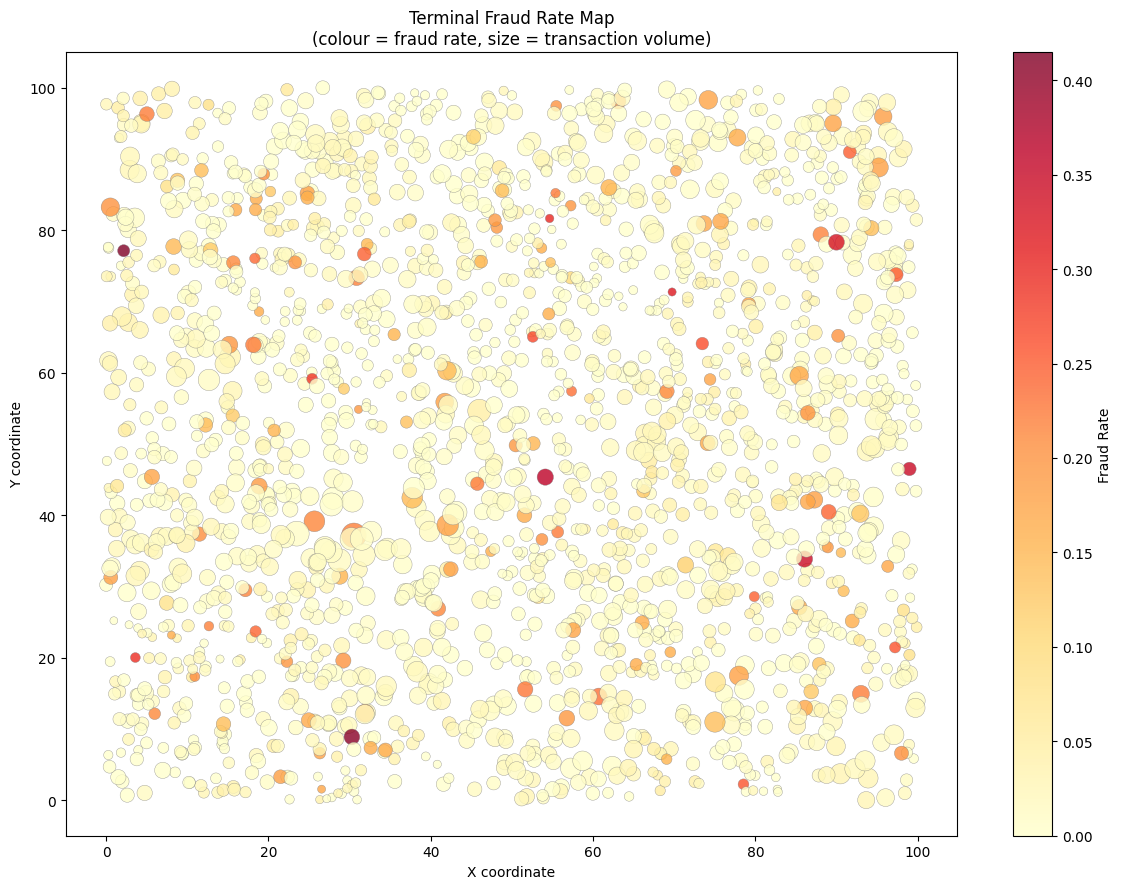

Top 10 highest-risk terminals:
 TERMINAL_ID  fraud_rate  tx_count
        1472    0.414894        94
        1594    0.407821       179
        1496    0.362245       196
         870    0.346774       124
         773    0.343590       195
        1902    0.331551       187
        1890    0.320000        25
         647    0.300000        30
         558    0.294118        51
         636    0.285714        70


In [5]:
# ── 3. Terminal Fraud Rate Map (colour = fraud rate, size = volume) ─────────
active = terminal_stats[terminal_stats['tx_count'] >= 20].copy()

plt.figure(figsize=(12, 9))
sc = plt.scatter(
    active['x_terminal_id'], active['y_terminal_id'],
    c=active['fraud_rate'], cmap='YlOrRd',
    s=active['tx_count'] / active['tx_count'].max() * 300 + 20,
    alpha=0.8, edgecolors='grey', linewidths=0.3
)
plt.colorbar(sc, label='Fraud Rate')
plt.title('Terminal Fraud Rate Map\n(colour = fraud rate, size = transaction volume)')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.tight_layout()
plt.show()

high_risk = active.nlargest(10, 'fraud_rate')[['TERMINAL_ID','fraud_rate','tx_count']]
print("Top 10 highest-risk terminals:")
print(high_risk.to_string(index=False))

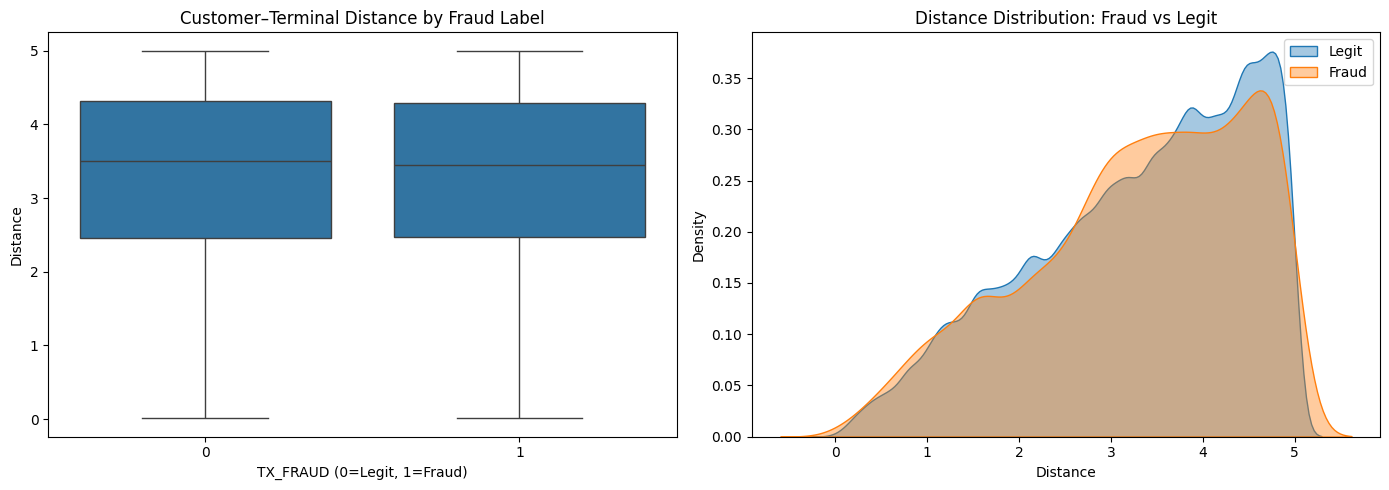

             count  mean   std   min   25%   50%   75%  max
TX_FRAUD                                                   
0         284649.0  3.31  1.19  0.01  2.46  3.51  4.32  5.0
1           6582.0  3.28  1.20  0.02  2.47  3.45  4.29  5.0


In [6]:
# ── 4. Customer–Terminal Distance vs Fraud ──────────────────────────────────
merged['distance'] = np.sqrt(
    (merged['x_customer_id'] - merged['x_terminal_id'])**2 +
    (merged['y_customer_id'] - merged['y_terminal_id'])**2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='TX_FRAUD', y='distance', data=merged, ax=axes[0])
axes[0].set_title('Customer–Terminal Distance by Fraud Label')
axes[0].set_xlabel('TX_FRAUD (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Distance')

for label, grp in merged.groupby('TX_FRAUD'):
    sns.kdeplot(grp['distance'], ax=axes[1],
                label='Fraud' if label else 'Legit', fill=True, alpha=0.4)
axes[1].set_title('Distance Distribution: Fraud vs Legit')
axes[1].set_xlabel('Distance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(merged.groupby('TX_FRAUD')['distance'].describe().round(2))

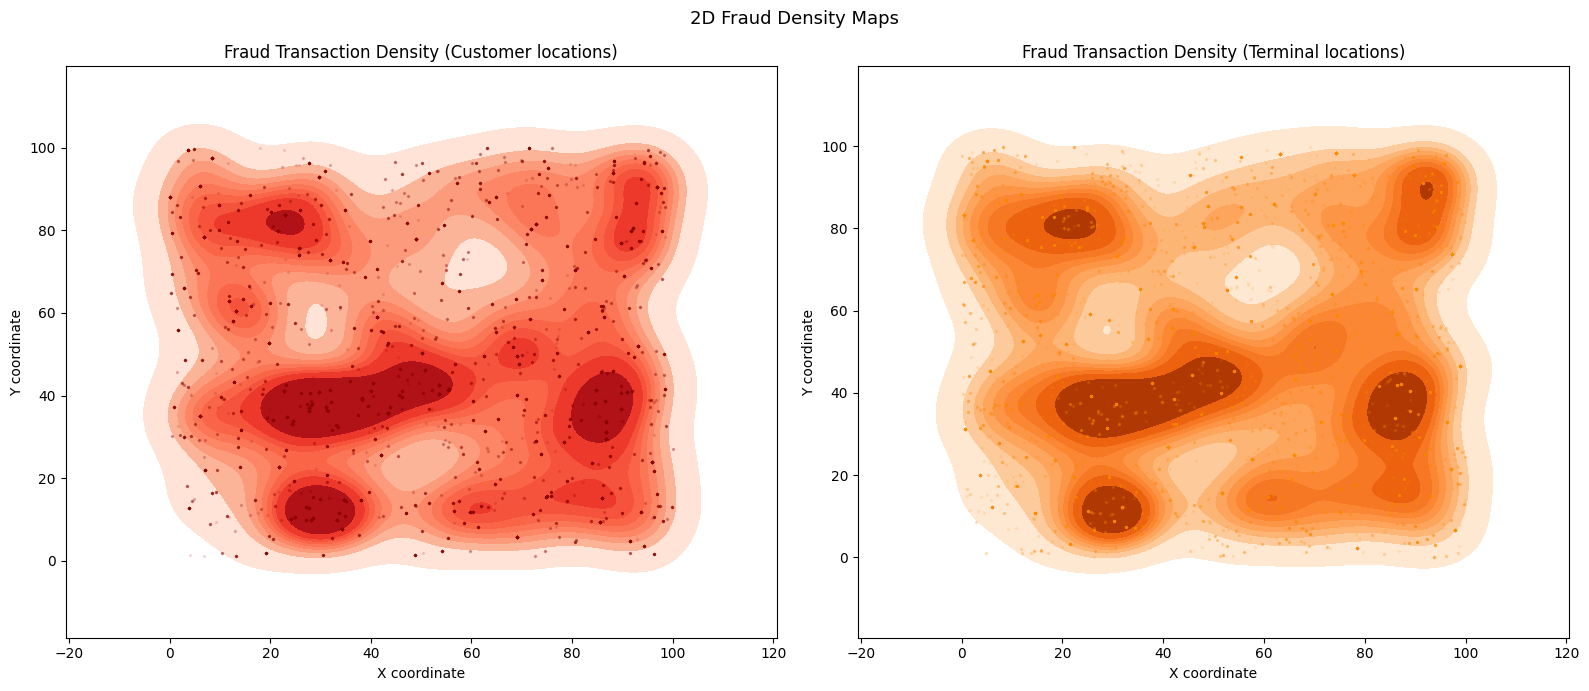

In [7]:
# ── 5. 2D Density: Fraud Transaction Origin (Customer Coordinates) ──────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].set_title('Fraud Transaction Density (Customer locations)')
sns.kdeplot(x=fraud_txns['x_customer_id'], y=fraud_txns['y_customer_id'],
            cmap='Reds', fill=True, thresh=0.05, ax=axes[0])
axes[0].scatter(fraud_txns['x_customer_id'], fraud_txns['y_customer_id'],
                s=2, alpha=0.1, color='darkred')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')

axes[1].set_title('Fraud Transaction Density (Terminal locations)')
sns.kdeplot(x=fraud_txns['x_terminal_id'], y=fraud_txns['y_terminal_id'],
            cmap='Oranges', fill=True, thresh=0.05, ax=axes[1])
axes[1].scatter(fraud_txns['x_terminal_id'], fraud_txns['y_terminal_id'],
                s=2, alpha=0.1, color='darkorange')
axes[1].set_xlabel('X coordinate')
axes[1].set_ylabel('Y coordinate')

plt.suptitle('2D Fraud Density Maps', fontsize=13)
plt.tight_layout()
plt.show()